# CAPSTONE PROJEKT - Gruppe D
Notebook 1: Business Understanding und Data Understanding

Wir folgen bewusst dem CRISP-DM-Prozess:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment / Interpretation

## 1. Business Understanding

Genaue Prognosen von Goldpreisen helfen Investoren, Finanzinstituten und Rohstoffhändlern dabei, Kauf-, Halte- oder Verkaufsentscheidungen zu treffen. Sie unterstützen zudem die Portfolioallokation, das Risikomanagement und Absicherungsstrategien (Hedging).

Stakeholder (Interessengruppen):
- Investoren 
- Banken 
- Rohstoffhändler 
- Portfolio-Manager

## 2. Data Understanding
In diesem Kapitel wird untersucht ob die Daten fehlende Werte enthalten.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# Gold Futures Ticker laden
gold = yf.Ticker("GC=F")

# Alle verfügbaren Daten in Tagesschritten abrufen
df = gold.history(start="2000-09-01", interval="1d")

# Die prozentuale Veränderung zum Vortag berechnen
df['Change %'] = df['Close'].pct_change()

# Spalten auswählen
spaltenname = df.columns.tolist()
print('Spaltenname prüfen' , spaltenname)

#df = df[['Close', 'Open', 'High', 'Low', 'Volume', 'Change %']]


# Die Daten als CSV-Datei speichern
#df.to_csv("../Data/goldpreis_seit_2000.csv")

# print(df.tail())
#Vermutung: Datum ist ein Index
print(df['Open'].head())

Spaltenname prüfen ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Change %']
Date
2000-09-01 00:00:00-04:00    277.000000
2000-09-05 00:00:00-04:00    275.799988
2000-09-06 00:00:00-04:00    274.200012
2000-09-07 00:00:00-04:00    274.000000
2000-09-08 00:00:00-04:00    273.299988
Name: Open, dtype: float64


In [2]:
# Die Daten als CSV-Datei speichern
df.to_csv("../Data/goldpreis_seit_2000.csv")

In [3]:
df.size

51928

In [4]:
#Vermutung: Datum ist ein Index
df.index

#Ergebnis: Datum ist aktuell ein Index.

DatetimeIndex(['2000-09-01 00:00:00-04:00', '2000-09-05 00:00:00-04:00',
               '2000-09-06 00:00:00-04:00', '2000-09-07 00:00:00-04:00',
               '2000-09-08 00:00:00-04:00', '2000-09-11 00:00:00-04:00',
               '2000-09-12 00:00:00-04:00', '2000-09-13 00:00:00-04:00',
               '2000-09-14 00:00:00-04:00', '2000-09-15 00:00:00-04:00',
               ...
               '2026-07-06 00:00:00-04:00', '2026-07-07 00:00:00-04:00',
               '2026-07-08 00:00:00-04:00', '2026-07-09 00:00:00-04:00',
               '2026-07-10 00:00:00-04:00', '2026-07-13 00:00:00-04:00',
               '2026-07-14 00:00:00-04:00', '2026-07-15 00:00:00-04:00',
               '2026-07-16 00:00:00-04:00', '2026-07-17 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=6491, freq=None)

In [5]:
# Index droppen:
df_prep = df.reset_index()


In [6]:
spaltenname2 = df_prep.columns.tolist()
print(spaltenname2)

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Change %']


In [7]:
# Die Daten als CSV-Datei speichern
#df.to_csv("../Data/goldpreis_seit_2000.csv")

print(df_prep.tail())

                          Date         Open         High          Low  \
6486 2026-07-13 00:00:00-04:00  4081.000000  4081.000000  3985.899902   
6487 2026-07-14 00:00:00-04:00  3995.699951  4091.199951  3986.500000   
6488 2026-07-15 00:00:00-04:00  4049.100098  4070.100098  4019.399902   
6489 2026-07-16 00:00:00-04:00  4030.500000  4030.500000  3972.600098   
6490 2026-07-17 00:00:00-04:00  3980.100098  4012.199951  3963.000000   

            Close  Volume  Dividends  Stock Splits  Change %  
6486  3997.000000     679        0.0           0.0 -0.026096  
6487  4061.100098    1281        0.0           0.0  0.016037  
6488  4044.000000     374        0.0           0.0 -0.004211  
6489  3985.600098     374        0.0           0.0 -0.014441  
6490  3993.000000   66195        0.0           0.0  0.001857  


In [8]:
# Uhrzeit aus Datumsfeld entfernen
df_prep['Date'] = pd.to_datetime(df_prep['Date'],format="%Y-%m-%d")

In [9]:
# Check
df_prep['Date']

0      2000-09-01 00:00:00-04:00
1      2000-09-05 00:00:00-04:00
2      2000-09-06 00:00:00-04:00
3      2000-09-07 00:00:00-04:00
4      2000-09-08 00:00:00-04:00
                  ...           
6486   2026-07-13 00:00:00-04:00
6487   2026-07-14 00:00:00-04:00
6488   2026-07-15 00:00:00-04:00
6489   2026-07-16 00:00:00-04:00
6490   2026-07-17 00:00:00-04:00
Name: Date, Length: 6491, dtype: datetime64[s, America/New_York]

In [10]:
print(df_prep['Date'].dtype)

datetime64[s, America/New_York]


In [11]:
#Anzahl fehlende Werte pro Spalte
df_prep.isna().sum()



Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Change %        1
dtype: int64

In [12]:
# Prüfe wo im Datensatz leere Wert verhanden sind
zeilen, spalten = np.where(df_prep.isna())

for z, s in zip(zeilen, spalten):
    print(f"Leere Zelle gefunden in Zeile: {df_prep.index[z]} | Spalte: {df_prep.columns[s]}")

Leere Zelle gefunden in Zeile: 0 | Spalte: Change %


In [13]:
# Leerzeichen prüfen
maske_leerzeichen = df_prep.map(lambda x: isinstance(x, str) and x.strip() == '' and len(x) > 0)

# Koordinaten (Zeile und Spalte) auslesen
zeilen, spalten = np.where(maske_leerzeichen)

for z, s in zip(zeilen, spalten):
    print(f"Reines Leerzeichen gefunden -> Zeile: {df_prep.index[z]} | Spalte: {df_prep.columns[s]}")



In [14]:
df_prep.fillna(0.0, inplace=True)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Change %
0,2000-09-01 00:00:00-04:00,277.000000,277.000000,277.000000,277.000000,0,0.0,0.0,0.000000
1,2000-09-05 00:00:00-04:00,275.799988,275.799988,275.799988,275.799988,2,0.0,0.0,-0.004332
2,2000-09-06 00:00:00-04:00,274.200012,274.200012,274.200012,274.200012,0,0.0,0.0,-0.005801
3,2000-09-07 00:00:00-04:00,274.000000,274.000000,274.000000,274.000000,125,0.0,0.0,-0.000729
4,2000-09-08 00:00:00-04:00,273.299988,273.299988,273.299988,273.299988,0,0.0,0.0,-0.002555
...,...,...,...,...,...,...,...,...,...
6486,2026-07-13 00:00:00-04:00,4081.000000,4081.000000,3985.899902,3997.000000,679,0.0,0.0,-0.026096
6487,2026-07-14 00:00:00-04:00,3995.699951,4091.199951,3986.500000,4061.100098,1281,0.0,0.0,0.016037
6488,2026-07-15 00:00:00-04:00,4049.100098,4070.100098,4019.399902,4044.000000,374,0.0,0.0,-0.004211
6489,2026-07-16 00:00:00-04:00,4030.500000,4030.500000,3972.600098,3985.600098,374,0.0,0.0,-0.014441


In [15]:
# Check: Spalten
spaltenname = df_prep.columns.tolist()
print(spaltenname)

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Change %']


In [16]:
spaltenanzahl = df_prep.columns.size
print(spaltenanzahl)

9


In [17]:
sizedf = df_prep.size
print(sizedf)

58419


In [18]:
df_prep.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Change %
0,2000-09-01 00:00:00-04:00,277.000000,277.000000,277.000000,277.000000,0,0.0,0.0,0.000000
1,2000-09-05 00:00:00-04:00,275.799988,275.799988,275.799988,275.799988,2,0.0,0.0,-0.004332
2,2000-09-06 00:00:00-04:00,274.200012,274.200012,274.200012,274.200012,0,0.0,0.0,-0.005801
3,2000-09-07 00:00:00-04:00,274.000000,274.000000,274.000000,274.000000,125,0.0,0.0,-0.000729
4,2000-09-08 00:00:00-04:00,273.299988,273.299988,273.299988,273.299988,0,0.0,0.0,-0.002555


In [19]:
referenz_kalender = pd.DataFrame({'Date': pd.date_range(start="2000-09-01", end="2026-07-12", freq="D")})
referenz_kalender.head()

,Date
0,2000-09-01
1,2000-09-02
2,2000-09-03
3,2000-09-04
4,2000-09-05


In [20]:
import pandas as pd

dates_ref = pd.to_datetime(referenz_kalender['Date'], utc=True, errors='coerce')
dates_dat = pd.to_datetime(df_prep['Date'], utc=True, errors='coerce')


set_referenz = set(dates_ref.dt.date.dropna())
set_daten = set(dates_dat.dt.date.dropna())

fehlende_tage_liste = sorted(list(set_referenz - set_daten))

# 4. Ergebnis zurück in ein sauberes DataFrame gießen
fehlende_tage_df = pd.DataFrame({'Datum': pd.to_datetime(fehlende_tage_liste)})

print("\nDie ersten fehlenden Tage:")
print(fehlende_tage_df.head(10))
print(fehlende_tage_df.size)


Die ersten fehlenden Tage:
       Datum
0 2000-09-02
1 2000-09-03
2 2000-09-04
3 2000-09-09
4 2000-09-10
5 2000-09-16
6 2000-09-17
7 2000-09-23
8 2000-09-24
9 2000-09-30
2960


In [21]:
# Ergebnis: Uns fehlen 2960 Tage in den Quelldaten bezogen auf einen Kalendervergleich
# Check wie viele Tage davon Wochenende und Feiertage sind:
import holidays
#print(holidays.list_supported_countries())

from datetime import date
import holidays
jahre_int = list(range(2000, 2027))
liste_feiertage = []
for y in jahre_int:
    for h in holidays.US(years=y).items():
        #print(h)
        liste_feiertage.append(h)
        

print(liste_feiertage)
feiertag_df = pd.DataFrame(liste_feiertage, columns=["Datum","Name des Feiertags"])
print(feiertag_df.head())

[(datetime.date(2000, 1, 1), "New Year's Day"), (datetime.date(2000, 5, 29), 'Memorial Day'), (datetime.date(2000, 7, 4), 'Independence Day'), (datetime.date(2000, 9, 4), 'Labor Day'), (datetime.date(2000, 11, 23), 'Thanksgiving Day'), (datetime.date(2000, 12, 25), 'Christmas Day'), (datetime.date(2000, 1, 17), 'Martin Luther King Jr. Day'), (datetime.date(2000, 2, 21), "Washington's Birthday"), (datetime.date(2000, 10, 9), 'Columbus Day'), (datetime.date(2000, 11, 11), 'Veterans Day'), (datetime.date(2000, 11, 10), 'Veterans Day (observed)'), (datetime.date(2001, 1, 1), "New Year's Day"), (datetime.date(2001, 5, 28), 'Memorial Day'), (datetime.date(2001, 7, 4), 'Independence Day'), (datetime.date(2001, 9, 3), 'Labor Day'), (datetime.date(2001, 11, 22), 'Thanksgiving Day'), (datetime.date(2001, 12, 25), 'Christmas Day'), (datetime.date(2001, 1, 15), 'Martin Luther King Jr. Day'), (datetime.date(2001, 2, 19), "Washington's Birthday"), (datetime.date(2001, 10, 8), 'Columbus Day'), (datet

In [22]:
from datetime import datetime
start="2000-09-01"
ende="2026-07-12"
soll_kalender = pd.date_range(start=start, end=ende, freq="D")
soll_kalender_lst = soll_kalender.tolist()
liste_we = []
for d in soll_kalender_lst:
    # Samstag prüfen (5)
    if d.weekday() == 5:
        liste_we.append(d)
    if d.weekday() == 6:
        liste_we.append(d)

print(liste_we)
we_df = pd.DataFrame(liste_we, columns=["Datum"])
print(we_df.head())

[Timestamp('2000-09-02 00:00:00'), Timestamp('2000-09-03 00:00:00'), Timestamp('2000-09-09 00:00:00'), Timestamp('2000-09-10 00:00:00'), Timestamp('2000-09-16 00:00:00'), Timestamp('2000-09-17 00:00:00'), Timestamp('2000-09-23 00:00:00'), Timestamp('2000-09-24 00:00:00'), Timestamp('2000-09-30 00:00:00'), Timestamp('2000-10-01 00:00:00'), Timestamp('2000-10-07 00:00:00'), Timestamp('2000-10-08 00:00:00'), Timestamp('2000-10-14 00:00:00'), Timestamp('2000-10-15 00:00:00'), Timestamp('2000-10-21 00:00:00'), Timestamp('2000-10-22 00:00:00'), Timestamp('2000-10-28 00:00:00'), Timestamp('2000-10-29 00:00:00'), Timestamp('2000-11-04 00:00:00'), Timestamp('2000-11-05 00:00:00'), Timestamp('2000-11-11 00:00:00'), Timestamp('2000-11-12 00:00:00'), Timestamp('2000-11-18 00:00:00'), Timestamp('2000-11-19 00:00:00'), Timestamp('2000-11-25 00:00:00'), Timestamp('2000-11-26 00:00:00'), Timestamp('2000-12-02 00:00:00'), Timestamp('2000-12-03 00:00:00'), Timestamp('2000-12-09 00:00:00'), Timestamp('20

In [23]:
# TODO: Methode Reparieren.
# Zielbild alle Feiertage und Wochenenden in einem Dataframe und Daten sind korrekt aufsteigend sortiert.
# Anschließend mit Df (fehlende_tage_df)von Oben vergelichen ob dies alle fehlenden WErte erklärt.

df_weHol = pd.concat([feiertag_df,we_df])
df_weHol.drop(columns=['Name des Feiertags'], inplace=True)
#feiertag_df.size #614
#we_df.size #2700
df_weHol['Datum'] = pd.to_datetime(df_weHol['Datum'], errors='coerce').dt.floor('D')


df_weHol.drop_duplicates(inplace=True)
df_weHol.sort_values(by='Datum', ascending=True, inplace=True)
df_weHol_final = df_weHol.sort_values(by='Datum', ascending=True).reset_index(drop=True)
print(df_weHol_final['Datum'])

0      2000-01-01
1      2000-01-17
2      2000-02-21
3      2000-05-29
4      2000-07-04
          ...    
2971   2026-09-07
2972   2026-10-12
2973   2026-11-11
2974   2026-11-26
2975   2026-12-25
Name: Datum, Length: 2976, dtype: datetime64[us]


In [24]:
#Falsch
#dates_ref = pd.to_datetime(referenz_kalender['Date'], utc=True, errors='coerce')
#dates_dat = pd.to_datetime(df_prep['Date'], utc=True, errors='coerce')
dates_ref = pd.to_datetime(df_prep['Date'], utc=True, errors='coerce')
dates_dat = pd.to_datetime(df_weHol['Datum'], utc=True, errors='coerce')


set_referenz = set(dates_ref.dt.date.dropna())
set_daten = set(dates_dat.dt.date.dropna())

fehlende_tage_liste = sorted(list(set_referenz - set_daten))

# 4. Ergebnis zurück in ein sauberes DataFrame gießen
vergleichs_df = pd.DataFrame({'Datum': pd.to_datetime(fehlende_tage_liste)})

print("\nDie ersten fehlenden Tage:")
print(vergleichs_df.head(10))
print(vergleichs_df.size)


Die ersten fehlenden Tage:
       Datum
0 2000-09-01
1 2000-09-05
2 2000-09-06
3 2000-09-07
4 2000-09-08
5 2000-09-11
6 2000-09-12
7 2000-09-13
8 2000-09-14
9 2000-09-15
6436


In [25]:
#Daten ohne Leerzeichen speichern.
df_prep.to_csv("../Data/goldpreis_seit_2000_prep.csv")

In [26]:
# Schlusskurs des Tages als Preis nutzen.
w = df_prep['Close'].tolist()
print(w)

[277.0, 275.79998779296875, 274.20001220703125, 274.0, 273.29998779296875, 273.1000061035156, 272.8999938964844, 272.79998779296875, 272.3999938964844, 272.29998779296875, 271.3999938964844, 271.8999938964844, 269.0, 270.29998779296875, 271.79998779296875, 274.1000061035156, 273.8999938964844, 278.3999938964844, 275.6000061035156, 273.6000061035156, 273.1000061035156, 271.6000061035156, 270.29998779296875, 270.6000061035156, 269.29998779296875, 270.1000061035156, 272.3999938964844, 270.5, 276.3999938964844, 272.3999938964844, 271.5, 271.1000061035156, 270.29998779296875, 270.1000061035156, 271.20001220703125, 270.1000061035156, 270.1000061035156, 266.20001220703125, 264.8999938964844, 264.3999938964844, 264.29998779296875, 264.8999938964844, 263.8999938964844, 264.3999938964844, 264.6000061035156, 264.5, 264.29998779296875, 265.0, 265.79998779296875, 264.5, 264.29998779296875, 264.8999938964844, 265.1000061035156, 265.79998779296875, 265.70001220703125, 266.29998779296875, 265.70001220

In [27]:
# Erste 10 Tage visualisieren zu denen wir Werte haben
w2 = w[0:10]
print(w2)


[277.0, 275.79998779296875, 274.20001220703125, 274.0, 273.29998779296875, 273.1000061035156, 272.8999938964844, 272.79998779296875, 272.3999938964844, 272.29998779296875]


In [28]:
# Schlusskurs des Tages als Preis nutzen.
date_d = df_prep['Date'].tolist()
print(date_d)

[Timestamp('2000-09-01 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-05 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-06 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-07 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-08 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-11 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-12 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-13 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-14 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-15 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-18 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-19 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-20 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-21 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-22 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-25 00:00:00-0400', tz='America/New_York'), Timesta

In [29]:
date_d_first30 = date_d[0:10]
print(date_d_first30)

[Timestamp('2000-09-01 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-05 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-06 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-07 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-08 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-11 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-12 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-13 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-14 00:00:00-0400', tz='America/New_York'), Timestamp('2000-09-15 00:00:00-0400', tz='America/New_York')]


/var/folders/m_/dmqs8npd07x_q9r4vh5w8yz80000gn/T/ipykernel_34995/3802036487.py:11: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  full_time_range = pd.date_range(start=start_date, end=end_date, freq='d')


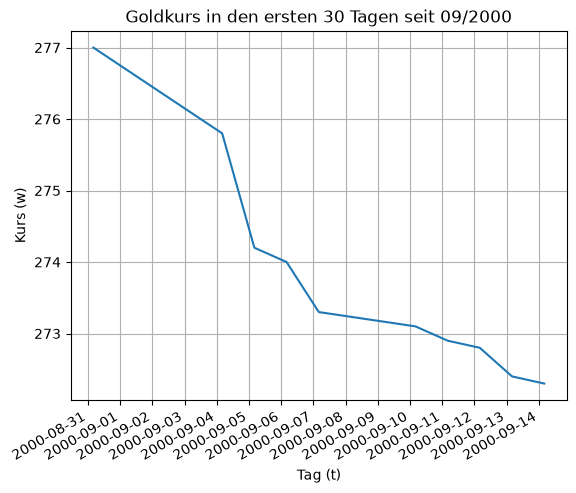

In [30]:
# Goldkurs visualisieren
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import warnings

# Data for plotting
w = w2
start_date = pd.to_datetime("2000-09-01")
end_date = pd.to_datetime("2026-07-12")
full_time_range = pd.date_range(start=start_date, end=end_date, freq='d')
t = date_d_first30

fig, ax = plt.subplots()
ax.plot(t, w)


        
 
ax.set(xlabel='Tag (t)', ylabel='Kurs (w)',
       title='Goldkurs in den ersten 30 Tagen seit 09/2000') 

# Rotieren der X-Achsen-Beschriftung, damit sich die Datumsangaben nicht überschneiden
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))        
ax.grid()

fig.savefig("test.png")
plt.show()

<bound method IndexOpsMixin.tolist of DatetimeIndex(['2000-09-01', '2000-09-02', '2000-09-03', '2000-09-04',
               '2000-09-05', '2000-09-06', '2000-09-07', '2000-09-08',
               '2000-09-09', '2000-09-10',
               ...
               '2026-07-03', '2026-07-04', '2026-07-05', '2026-07-06',
               '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10',
               '2026-07-11', '2026-07-12'],
              dtype='datetime64[us]', length=9446, freq='D')>


/var/folders/m_/dmqs8npd07x_q9r4vh5w8yz80000gn/T/ipykernel_34995/423268981.py:11: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  full_time_range = pd.date_range(start=start_date, end=end_date, freq='d')


ValueError: x and y must have same first dimension, but have shapes (1,) and (6491,)

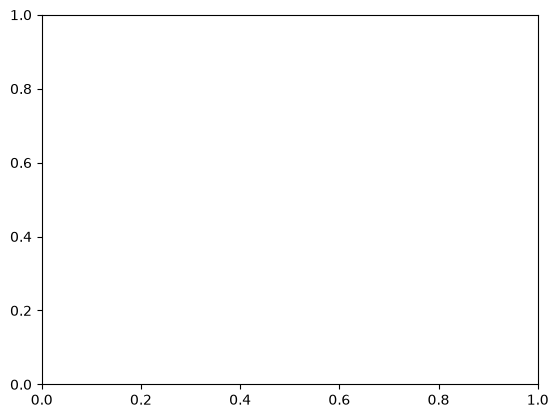

In [ ]:
# Goldkurs visualisieren
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import warnings

# Data for plotting
w = df['Close'].tolist()
#start_date = pd.to_datetime("2000-09-01")
#end_date = pd.to_datetime("2026-07-12")
#full_time_range = pd.date_range(start=start_date, end=end_date, freq='d')
#t = full_time_range.tolist
t= df['Date'].tolist()
print(t)
fig, ax = plt.subplots()
ax.plot(t,w)

ax.set(xlabel='Tag (t)', ylabel='Kurs (w)',
       title='Goldkurs seit 09/2000')

# Rotieren der X-Achsen-Beschriftung, damit sich die Datumsangaben nicht überschneiden
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))        
ax.grid()

fig.savefig("goldkurs_gesamt.png")
plt.show()